# Ноутбуки для GitHub. 
---

## Тема 1 - Моделирование геометрической вероятности
---

### Задача 
> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше >площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.


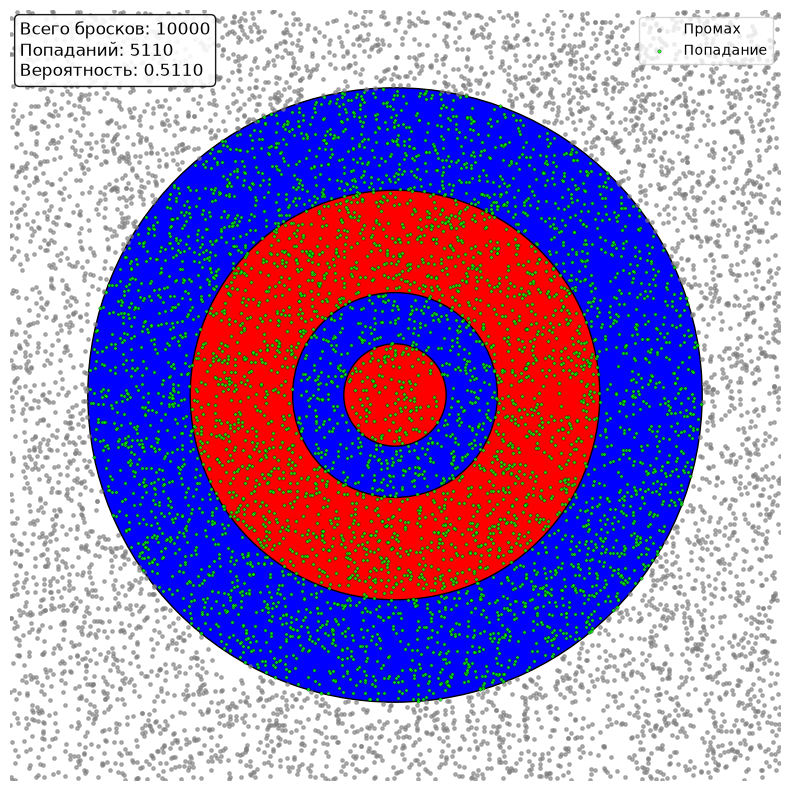

── Параметры задачи ──
Сторона стены 4
Площадь стены 16
Площадь круга 8.0
Радиус круга 1.5958

Всего бросков 10000
Попаданий: 5110


In [13]:
import numpy as np
import matplotlib.pyplot as plt


def area_calc(side):
    AreaWall = side * side
    AreaCircle = AreaWall / 2
    RadiusCircle = np.sqrt(AreaCircle / np.pi)
    return side, AreaWall, AreaCircle, RadiusCircle


def simulate_throws(side, R, n, seed=None):
    np.random.seed(seed)
    x = np.random.uniform(-side / 2, side / 2, n)
    y = np.random.uniform(-side / 2, side / 2, n)
    inside = x ** 2 + y ** 2 <= R ** 2
    return x, y, inside


def draw_target(ax, R, rings=3):
    colors = ['blue', 'red', 'blue']
    for i in range(rings):
        r = R * (rings - i) / rings
        color = colors[i % len(colors)]
        ax.add_patch(plt.Circle(
            (0, 0), r,
            facecolor=color,
            edgecolor='black',
            linewidth=1
        ))
    ax.add_patch(plt.Circle(
        (0, 0), R / rings / 2,
        facecolor='red',
        edgecolor='black',
        linewidth=1
    ))


def draw_shots(ax, x, y, inside):
    ax.scatter(x[~inside], y[~inside],
               s=6, color='gray', alpha=0.6, label='Промах')
    ax.scatter(x[inside], y[inside],
               s=6, color='lime', alpha=0.8, edgecolors='black',
               linewidths=0.3, label='Попадание')


def draw_info(ax, n, hits, side):
    prob = hits / n
    text = (f'Всего бросков: {n}\n'
            f'Попаданий: {hits}\n'
            f'Вероятность: {prob:.4f}')
    ax.text(
        -side / 2 + 0.05, side / 2 - 0.05, text,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white',
                  edgecolor='black', alpha=0.9)
    )


def plot_result(side, R, x, y, inside):
    fig, ax = plt.subplots(figsize=(8, 8))

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    draw_target(ax, R, rings=3)

    draw_shots(ax, x, y, inside)

    draw_info(ax, len(x), np.sum(inside), side)

    ax.legend(loc='upper right', fontsize=10)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-side / 2, side / 2)
    ax.set_ylim(-side / 2, side / 2)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


side, AreaWall, AreaCircle, RadiusCircle = area_calc(4)
N = 10000
x, y, inside = simulate_throws(side, RadiusCircle, N)
plot_result(side, RadiusCircle, x, y, inside)

print("── Параметры задачи ──")
print("Сторона стены", f"{side}")
print("Площадь стены", f"{AreaWall}")
print("Площадь круга", f"{AreaCircle}")
print("Радиус круга", f"{RadiusCircle:.4f}")
print()
print("Всего бросков", f"{N}")
print(f"Попаданий: {np.sum(inside)}")